Design and implement a Python-based Decision Support System (DSS) that uses a Hopfield Neural Network to model and optimize a ₹60,000 monthly budget while satisfying multiple financial goals.

The system should adopt a multi-goal decision strategy to handle constraints and provide intelligent recommendations.

Financial Goals
- Save ≥ 20% of income
- Spend ≤ 30% on necessities
- Allocate ≥ ₹5,000 to health & wellness
- Spend ≤ ₹3,000 on entertainment
- Expense Categories
- Rent & Utilities
- Groceries
- Transportation
- Health & Wellness
- Entertainment
- Savings
- Miscellaneous

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. SETUP PARAMETERS
INCOME = 60000
CATEGORIES = [
    'Rent',
    'Groceries',
    'Transport',
    'Health',
    'Entertainment',
    'Savings',
    'Miscellaneous'
]
N = len(CATEGORIES)

In [3]:
# Constraints (Financial Goals)
MIN_SAVINGS = 0.20 * INCOME # ₹12,000
MAX_RENT = 0.30 * INCOME # ₹18,000
MIN_HEALTH = 5000
MAX_ENT = 3000

In [ ]:
def calculate_energy(weights):
    budget = weights * INCOME
    energy = 0

    # Goal 1: Total budget must equal income
    energy += (sum(budget) - INCOME) ** 2 
# budget.sum()
    # Goal 2: Savings >= 20%
    if budget[5] < MIN_SAVINGS:
        energy += (MIN_SAVINGS - budget[5]) ** 2

    # Goal 3: Rent <= 30%
    if budget[0] > MAX_RENT:
        energy += (budget[0] - MAX_RENT) ** 2

    # Goal 4: Health >= 5000
    if budget[3] < MIN_HEALTH:
        energy += (MIN_HEALTH - budget[3]) ** 2

    # Goal 5: Entertainment <= 3000
    if budget[4] > MAX_ENT:
        energy += (budget[4] - MAX_ENT) ** 2

    return energy

In [5]:
def optimize_budget():

    # Initial random weights that sum to 1
    weights = np.random.dirichlet(np.ones(N), size=1)[0]

    for _ in range(5000):

        current_energy = calculate_energy(weights)

        # Randomly adjust weights
        nudge = np.random.normal(0, 0.01, N)

        new_weights = np.clip(weights + nudge, 0.01, 1)
        new_weights /= new_weights.sum()

        if calculate_energy(new_weights) < current_energy:
            weights = new_weights

    return weights * INCOME

In [6]:
# Run Optimization
optimized_budget = optimize_budget()
df_budget=pd.DataFrame({'Category': CATEGORIES,'Amount':optimized_budget})

In [7]:
# 4. VISUALIZATION (Recommendations)
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

C:\Users\jenis\AppData\Local\Temp\ipykernel_19128\2900676566.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


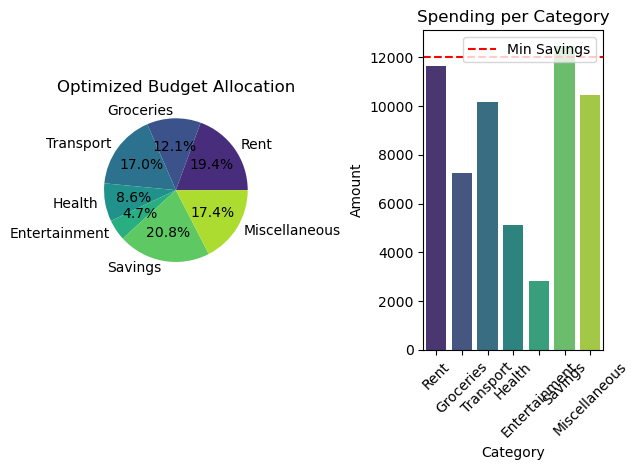

In [8]:
plt.subplot(1, 2, 1)
plt.pie(
    df_budget['Amount'],
    labels=df_budget['Category'],
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(df_budget))
)

plt.title("Optimized Budget Allocation")


# Bar Chart
plt.subplot(1, 2, 2)

sns.barplot(
    x='Category',
    y='Amount',
    data=df_budget,
    palette='viridis'
)

plt.xticks(rotation=45)
plt.axhline(
    MIN_SAVINGS,
    color='red',
    linestyle='--',
    label='Min Savings'
)

plt.title("Spending per Category")
plt.legend()
plt.tight_layout()
plt.show()


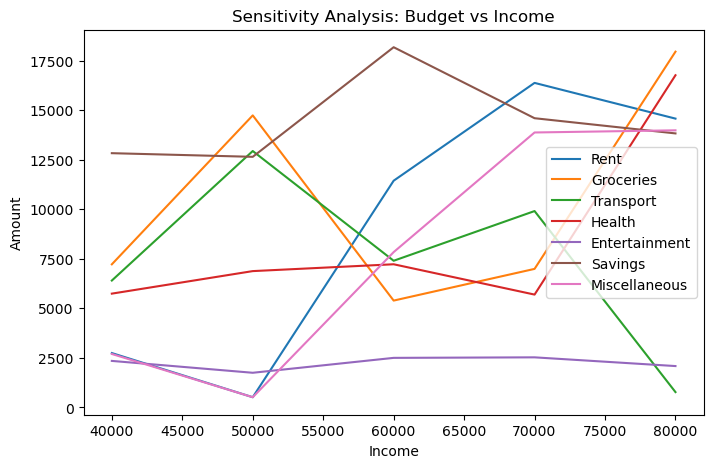

In [9]:
# 5. SENSITIVITY ANALYSIS
income_values = [40000, 50000, 60000, 70000, 80000]

results = []

for inc in income_values:
    INCOME = inc
    optimized = optimize_budget()
    results.append(optimized)

df_sensitivity = pd.DataFrame(
    results,
    columns=CATEGORIES
)

plt.figure(figsize=(8, 5))

for cat in CATEGORIES:
    plt.plot(
        income_values,
        df_sensitivity[cat],
        label=cat
    )

plt.xlabel("Income")
plt.ylabel("Amount")
plt.title("Sensitivity Analysis: Budget vs Income")
plt.legend()
plt.show()

In [10]:
# Check Goals
print(f"\nSavings Goal Met: {optimized_budget[5] >= MIN_SAVINGS}")
print(f"Total Budget Check: ₹{optimized_budget.sum():,.2f}")


Savings Goal Met: True
Total Budget Check: ₹60,000.00
